### Jonathan Steen
### MSDS, Bellevue University
### DSC 630: Predictive Analytics
### Instructor: Frank Neugebauer
### June 1st, 2025
### Final Project: Predicting Cannabis Use

## 1. Load, Inspect, and Clean Data
This dataset contains responses from the Canadian Community Health Survey. We'll focus on predicting cannabis use.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/Users/jonsteen/Desktop/Project/Data/health_dataset.csv")

# Initial shape and preview
df.shape, df.head()

((108252, 50),
    ADM_RNO1  Province  Health_region_ grouped  Gender  Marital_status  \
 0      1000        47                   47906       2               1   
 1    100005        47                   47906       1               1   
 2    100012        59                   59914       2               2   
 3    100015        13                   13904       1               2   
 4    100018        46                   46903       1               2   
 
    Household  Age  Worked_job_business  Edu_level  Gen_health_state  ...  \
 0          2    3                    1          3                 3  ...   
 1          2    5                    6          2                 3  ...   
 2          1    5                    6          1                 2  ...   
 3          1    5                    6          1                 3  ...   
 4          1    4                    2          3                 5  ...   
 
    Physical_vigorous_act_time  Work_hours   working_status   \
 0         

In [2]:
# View columns to see what features may not be needed.
df.columns.tolist()

['ADM_RNO1',
 'Province',
 'Health_region_ grouped',
 'Gender',
 'Marital_status',
 'Household',
 'Age',
 'Worked_job_business',
 'Edu_level',
 'Gen_health_state',
 'Life_satisfaction',
 'Mental_health_state',
 'Stress_level',
 'Work_stress',
 'Sense_belonging',
 'Weight_state',
 'BMI_12_17',
 'BMI_18_above',
 'Sleep_apnea',
 'High_BP',
 'High_cholestrol',
 'Diabetic',
 'Fatigue_syndrome',
 'Mood_disorder',
 'Anxiety_disorder',
 'Respiratory_chronic_con',
 'Musculoskeletal_con',
 'Cardiovascular_con',
 'Health_utility_indx',
 'Pain_status',
 'Act_improve_health',
 'Fruit_veg_con',
 'Smoked',
 'Tobaco_use',
 'weekly_alcohol',
 'Cannabies_use',
 'Drug_use',
 'Total_active_time',
 'Total_physical_act_time',
 'Other_physical_act_time',
 'Physical_vigorous_act_time',
 'Work_hours ',
 'working_status ',
 'Aboriginal_identity',
 'Birth_country',
 'Immigrant',
 'Insurance_cover',
 'Food_security',
 'Income_source',
 'Total_income']

In [3]:
# Fix typos and standardize column names
rename_map = {
    'Cannabies_use': 'Cannabis_use',
    'High_cholestrol': 'High_cholesterol',
    'Health_utility_indx': 'Health_utility_index',
    'Tobaco_use': 'Tobacco_use',
    'weekly_alcohol': 'Weekly_alcohol',
    'working_status': 'Working_status',
    'Musculoskeletal_con:': 'Musculoskeletal_con',
    'Cardiovascular_con:': 'Cardiovascular_con'
}

# Standardize column names
df.columns = [col.strip().replace(" ", "_") for col in df.columns]

# Fix column name typos
df.rename(columns=rename_map, inplace=True)

In [4]:
# Decoding dictionary for categorical variables
decoding_maps = {
    'Gender': {
        1: 'Male', 2: 'Female', 9: 'Not stated'
    },
    'Marital_status': {
        1: 'Married/Common-law', 2: 'Widowed/Divorced/Separated/Single', 3: 'Valid skip', 9: 'Not stated'
    },
    'Household': {
        1: 'Lives alone', 2: 'Household size 2 or more', 9: 'Not stated'
    },
    'Age': {
        1: '12-17', 2: '18-34', 3: '35-49', 4: '50-64', 5: '65+'
    },
    'Worked_job_business': {
        1: 'Yes', 2: 'No', 6: 'Valid skip', 7: 'Don’t know', 8: 'Refusal', 9: 'Not stated'
    },
    'Edu_level': {
        1: 'Less than secondary', 2: 'Secondary, no post-secondary', 3: 'Post-secondary', 9: 'Not stated'
    },
    'Gen_health_state': {
        1: 'Excellent', 2: 'Very good', 3: 'Good', 4: 'Fair', 5: 'Poor', 6: 'Don’t know', 9: 'Refusal'
    },
    'Mental_health_state': {
        1: 'Excellent', 2: 'Very good', 3: 'Good', 4: 'Fair', 5: 'Poor', 7: 'Don’t know', 8: 'Refusal', 9: 'Not stated'
    },
    'Stress_level': {
        1: 'Not at all', 2: 'Not very', 3: 'A bit', 4: 'Quite a bit', 5: 'Extremely', 7: 'Don’t know', 8: 'Refusal'
    },
    'Work_stress': {
        1: 'Not at all', 2: 'Not very', 3: 'A bit', 4: 'Quite a bit', 5: 'Extremely', 6: 'Valid skip', 7: 'Don’t know', 8: 'Refusal', 9: 'Not stated'
    },
    'Sense_belonging': {
        1: 'Very strong', 2: 'Somewhat strong', 3: 'Somewhat weak', 4: 'Very weak', 7: 'Don’t know', 8: 'Refusal', 9: 'Not stated'
    },
    'Weight_state': {
        1: 'Overweight', 2: 'Underweight', 3: 'Just about right', 6: 'Valid skip', 7: 'Don’t know', 8: 'Refusal', 9: 'Not stated'
    },
    'BMI_12_17': {
        1: 'Thin/Normal', 2: 'Overweight/Obese', 6: 'Valid skip', 9: 'Not stated'
    },
    'BMI_18_above': {
        1: 'Underweight/Normal', 2: 'Overweight/Obese', 6: 'Valid skip', 9: 'Not stated'
    },
    'Sleep_apnea': {
        1: 'Yes', 2: 'No', 7: 'Don’t know', 8: 'Refusal'
    },
    'High_BP': {
        1: 'Yes', 2: 'No', 7: 'Don’t know', 8: 'Refusal'
    },
    'High_cholesterol': {
        1: 'Yes', 2: 'No', 6: 'Valid skip', 7: 'Don’t know', 8: 'Refusal'
    },
    'Diabetic': {
        1: 'Yes', 2: 'No', 6: 'Valid skip', 7: 'Don’t know', 8: 'Refusal'
    },
    'Fatigue_syndrome': {
        1: 'Yes', 2: 'No', 7: 'Don’t know', 8: 'Refusal'
    },
    'Mood_disorder': {
        1: 'Yes', 2: 'No', 7: 'Don’t know', 8: 'Refusal'
    },
    'Anxiety_disorder': {
        1: 'Yes', 2: 'No', 7: 'Don’t know', 8: 'Refusal'
    },
    'Respiratory_chronic_con': {
        1: 'Yes', 2: 'No', 9: 'Not stated'
    },
    'Musculoskeletal_con': {
        1: 'Yes', 2: 'No', 6: 'Valid skip', 9: 'Not stated'
    },
    'Cardiovascular_con': {
        1: 'Yes', 2: 'No', 9: 'Not stated'
    },
    'Health_utility_index': {
        1: 'HUI < 0.8', 2: 'No', 9: 'Not stated'
    },
    'Pain_status': {
        1: 'No usual pain', 2: 'Usual pain', 9: 'Not stated'
    },
    'Act_improve_health': {
        1: 'Yes', 2: 'No', 6: 'Valid skip', 7: 'Don’t know', 8: 'Refusal'
    },
    'Fruit_veg_con': {
        1: '<5/day', 2: '5–10/day', 3: '>10/day', 6: 'Valid skip', 9: 'Not stated'
    },
    'Tobacco_use': {
        1: 'Yes', 2: 'No', 6: 'Valid skip', 7: 'Don’t know', 8: 'Refusal', 9: 'Not stated'
    },
    'Weekly_alcohol': {
        1: 'Yes', 2: 'No', 6: 'Valid skip', 7: 'Don’t know', 8: 'Refusal', 9: 'Not stated'
    },
    'Cannabis_use': {
        1: 'Non-medical', 2: 'Medical', 3: 'Both', 6: 'Valid skip', 7: "Don't know", 8: 'Refusal', 9: 'Not stated'
    },
    'Drug_use': {
        1: 'Used', 2: 'Not used', 3: 'Valid skip', 4: 'Not stated'
    },
    'Working_status': {
        1: 'Full-time', 2: 'Part-time', 6: 'Valid skip', 9: 'Not stated'
    },
    'Aboriginal_identity': {
        1: 'Yes', 2: 'No', 7: 'Don’t know', 8: 'Refusal', 9: 'Not stated'
    },
    'Birth_country': {
        1: 'Canada', 2: 'Other', 3: 'Not stated'
    },
    'Immigrant': {
        1: 'Immigrant', 2: 'Non-immigrant', 9: 'Not stated'
    },
    'Insurance_cover': {
        1: 'Yes', 2: 'No', 9: 'Not stated'
    },
    'Food_security': {
        0: 'Secure', 1: 'Marginally insecure', 2: 'Moderately insecure', 3: 'Severely insecure', 6: 'Valid skip', 9: 'Not stated'
    },
    'Income_source': {
        1: 'Wages/self-employment', 2: 'Other', 9: 'Not stated'
    },
    'Total_income': {
        1: '<$20k', 2: '$20k–$39k', 3: '$40k–$59k', 4: '$60k–$79k', 5: '$80k+', 9: 'Not stated'
    }
}

In [5]:
# Function to decode and clean data; Maps encoded values to their labels using decoding rules.
def decode_and_clean_dataframe(df, decoding_maps):
    import numpy as np

    # Apply decoding maps for categorical variables
    for col, mapping in decoding_maps.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    # Handle special numeric ranges

    # Smoked: map known codes
    if 'Smoked' in df.columns:
        df['Smoked'] = df['Smoked'].replace({
            996: 'Valid skip', 997: 'Don’t know', 998: 'Refusal', 999: 'Not stated'
        })

    # Work_hours: 96 = valid skip, 99 = not stated
    if 'Work_hours' in df.columns:
        df['Work_hours'] = df['Work_hours'].replace({
            96: 'Valid skip', 99: 'Not stated'
        })

    # Total activity time fields – mark skips/don’t knows/refusals
    activity_fields = [
        'Total_active_time', 'Total_physical_act_time',
        'Other_physical_act_time', 'Physical_vigorous_act_time'
    ]
    for col in activity_fields:
        if col in df.columns:
            df[col] = df[col].replace({
                99996: 'Valid skip', 9996: 'Valid skip', 99997: 'Don’t know', 99998: 'Refusal', 99999: 'Not stated'
            })

    return df

In [6]:
# Function to standardize invalid responses
def standardize_invalid_responses(df):
    import numpy as np

    # Define values to treat as missing
    invalid_values = ['Don’t know', 'Refusal', 'Not stated', 'Valid skip']
    
    # Replace invalid values with np.nan and ensure proper dtype handling
    df = df.replace(invalid_values, np.nan)
    df = df.infer_objects(copy=False)  # Ensures numeric columns stay numeric
    return df

In [7]:
# Function to encode target columns for modeling
def binarize_targets(df):
    df['Cannabis_user'] = df['Cannabis_use'].map(lambda x: 1 if x in ['Non-medical', 'Both'] else 0)
    df['Drug_user'] = df['Drug_use'].map(lambda x: 1 if x == 'Used' else 0)
    return df

In [8]:
# Apply cleaning steps
df_cleaned = decode_and_clean_dataframe(df, decoding_maps)
df_cleaned = binarize_targets(df_cleaned)
df_cleaned = standardize_invalid_responses(df_cleaned)

/var/folders/b9/btcs246d0nq_h6wm0br4bz380000gn/T/ipykernel_14632/3870645751.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(invalid_values, np.nan)


## 2. Exploratory Data Analysis (EDA)
Before proceeding with feature selection and modeling, let's explore the dataset to better understand the distribution and relationships of key variables.

### Target Variable Distribution
This plot shows how balanced the dataset is in terms of cannabis use.

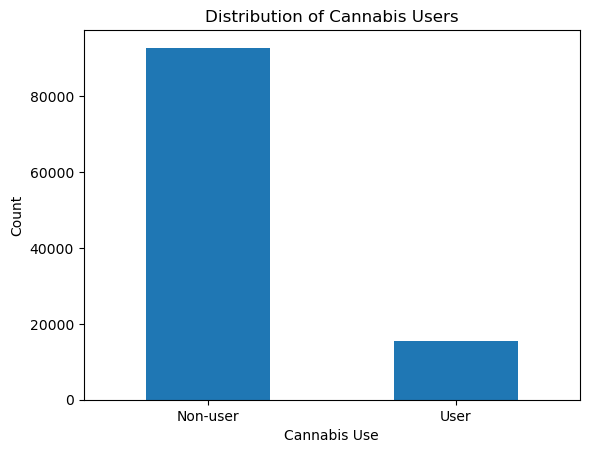

In [9]:
# Plot cannabis use breakdown
df_cleaned['Cannabis_user'].value_counts().plot(kind='bar', title='Distribution of Cannabis Users')
plt.xticks(ticks=[0, 1], labels=['Non-user', 'User'], rotation=0)
plt.xlabel('Cannabis Use')
plt.ylabel('Count')
plt.show()

**Rationale:**
Understanding the class distribution of the target variable is critical before modeling. An imbalanced dataset can bias the model toward the majority class and affect evaluation metrics.

**Interpretation:**
The plot shows that most respondents are non-users of cannabis, with a much smaller group identified as users. This imbalance suggests the need to consider techniques like class weighting or resampling to ensure the model doesn’t simply learn to predict the majority class.

### Categorical Variable vs. Cannabis Use
Visualizing the relationship between categorical predictors and cannabis use.

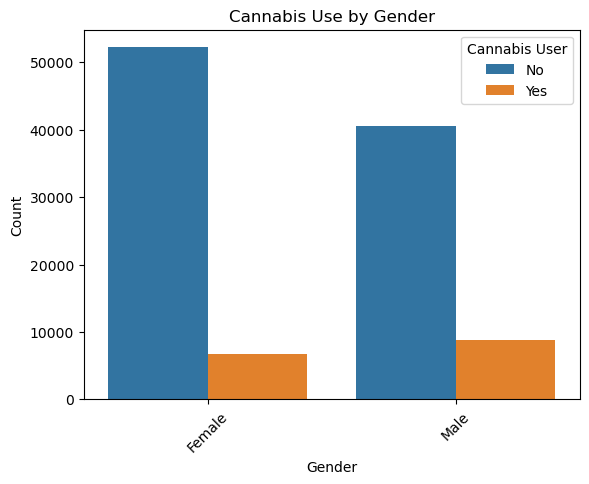

In [10]:
# Gender vs Cannabis Use
sns.countplot(x='Gender', hue='Cannabis_user', data=df_cleaned)
plt.title('Cannabis Use by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Cannabis User', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.show()

**Rationale:**
I'm exploring how categorical features relate to cannabis use to spot potential predictors for modeling.

**Interpretation:**
Males show a noticeably higher proportion of cannabis use compared to females. While both genders have more non-users overall, the relative difference in usage suggests gender may be a meaningful feature for prediction.

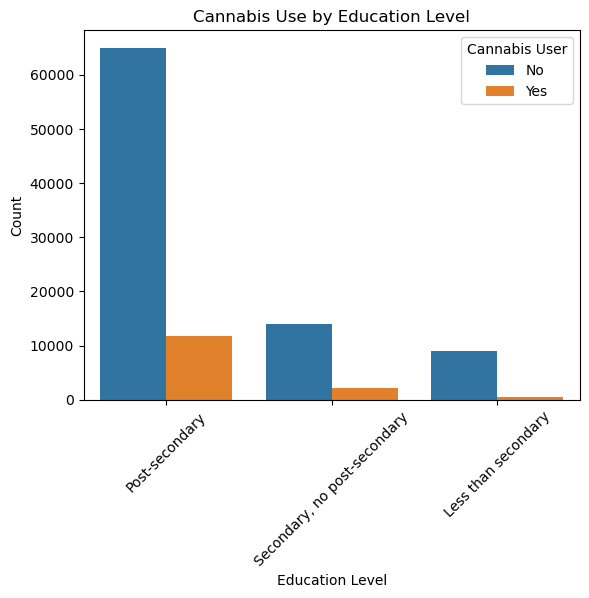

In [11]:
# Education Level vs Cannabis Use
sns.countplot(x='Edu_level', hue='Cannabis_user', data=df_cleaned)
plt.title('Cannabis Use by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Cannabis User', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.show()

**Rationale:**
Education level may influence lifestyle choices, including substance use. Exploring this helps identify social or behavioral patterns tied to cannabis consumption.

**Interpretation:**
Most respondents have post-secondary education, and this group also contains the largest number of cannabis users. However, within each education category, the proportion of users appears relatively consistent. This suggests education level may have a weaker relationship with cannabis use than other variables like gender or mental health, but it’s still worth testing in the model.

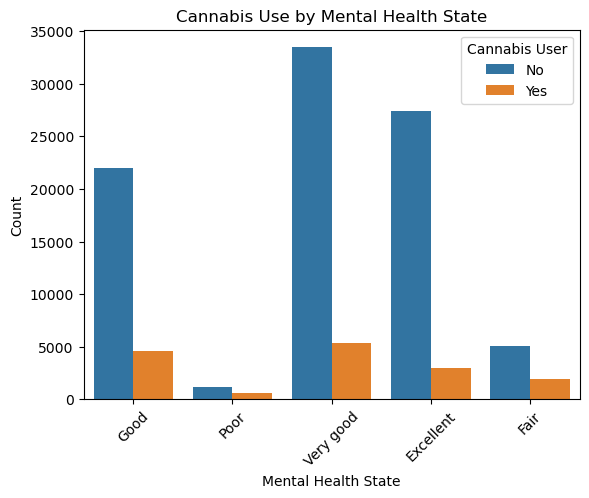

In [12]:
# Mental Health State vs Cannabis Use
sns.countplot(x='Mental_health_state', hue='Cannabis_user', data=df_cleaned)
plt.title('Cannabis Use by Mental Health State')
plt.xlabel('Mental Health State')
plt.ylabel('Count')
plt.legend(title='Cannabis User', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.show()

**Rationale:**
Mental health is often correlated with behavioral outcomes, including substance use. Visualizing this helps identify if cannabis use may be associated with perceived mental wellness.

**Interpretation:**
Cannabis use appears fairly consistent across mental health ratings, but there’s a slight increase in usage among those who rate their mental health as “Good” or “Very good.” Although counterintuitive, this could reflect complex relationships between stress management, perception, and lifestyle. It’s a variable worth keeping for further exploration during modeling.

### Numerical Variable Distributions
Distributions of some continuous variables like physical activity time.

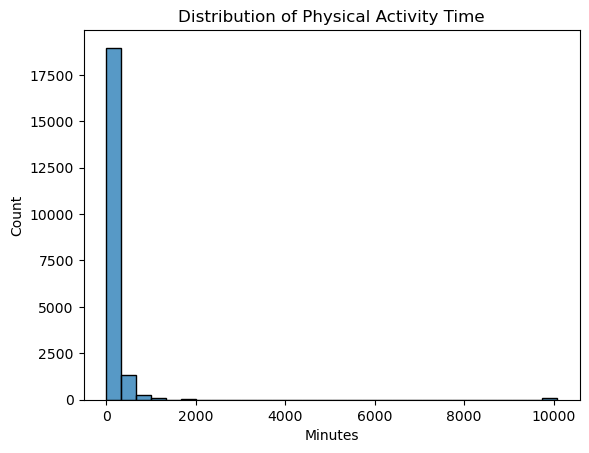

In [13]:
# Distribution of Physical Activity Time
sns.histplot(df_cleaned['Total_physical_act_time'].dropna(), bins=30)
plt.title('Distribution of Physical Activity Time')
plt.xlabel('Minutes')
plt.ylabel('Count')
plt.show()

**Rationale:**
Exploring continuous variables like physical activity time helps identify skewness, outliers, or the need for transformation before modeling.

**Interpretation:**
The distribution is highly right-skewed, with most individuals reporting low to moderate activity levels and a few extreme values. This suggests potential outliers or reporting errors that may require normalization or capping to reduce their impact on the model.

### Correlation Matrix
Correlation among numeric features to identify potential predictors.

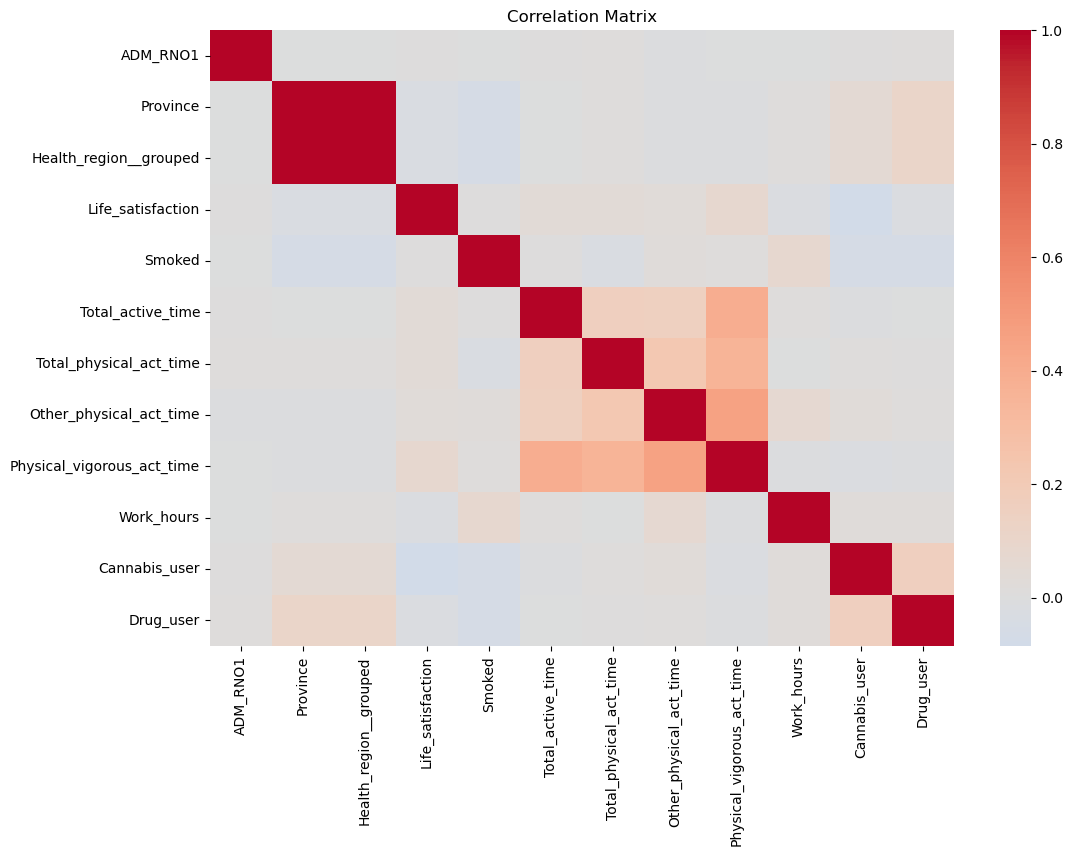

In [14]:
# Correlation heatmap
numeric_df = df_cleaned.select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

**Rationale:**
A correlation matrix helps identify multicollinearity between features and potential relationships with the target variable, guiding feature selection and engineering.

**Interpretation:**
There are moderate correlations among physical activity features, which may suggest redundancy. Cannabis use shows weak correlations with most numeric variables, but slight relationships with drug use and smoking behavior may still provide predictive value. Further modeling will clarify which features meaningfully contribute.

## 3. Feature Selection
We drop identifiers and sparse/uninformative features to prepare for modeling.

In [15]:
# View columns
df.columns.tolist()

['ADM_RNO1',
 'Province',
 'Health_region__grouped',
 'Gender',
 'Marital_status',
 'Household',
 'Age',
 'Worked_job_business',
 'Edu_level',
 'Gen_health_state',
 'Life_satisfaction',
 'Mental_health_state',
 'Stress_level',
 'Work_stress',
 'Sense_belonging',
 'Weight_state',
 'BMI_12_17',
 'BMI_18_above',
 'Sleep_apnea',
 'High_BP',
 'High_cholesterol',
 'Diabetic',
 'Fatigue_syndrome',
 'Mood_disorder',
 'Anxiety_disorder',
 'Respiratory_chronic_con',
 'Musculoskeletal_con',
 'Cardiovascular_con',
 'Health_utility_index',
 'Pain_status',
 'Act_improve_health',
 'Fruit_veg_con',
 'Smoked',
 'Tobacco_use',
 'Weekly_alcohol',
 'Cannabis_use',
 'Drug_use',
 'Total_active_time',
 'Total_physical_act_time',
 'Other_physical_act_time',
 'Physical_vigorous_act_time',
 'Work_hours',
 'Working_status',
 'Aboriginal_identity',
 'Birth_country',
 'Immigrant',
 'Insurance_cover',
 'Food_security',
 'Income_source',
 'Total_income',
 'Cannabis_user',
 'Drug_user']

In [16]:
# Drop sparse or target-leakage columns
drop_cols = [
    'ADM_RNO1', 'Cannabis_use', 'Drug_use', 'Cannabis_user', 'Drug_user',
    'BMI_12_17', 'Work_stress', 'Act_improve_health', 'Fruit_veg_con', 
    'Weekly_alcohol', 'Insurance_cover', 'Smoked', 'Income_source',
    'Total_active_time', 'Total_physical_act_time', 'Respiratory_chronic_con', 
    'Musculoskeletal_con', 'Cardiovascular_con', 'Health_utility_index', 
    'Other_physical_act_time', 'Physical_vigorous_act_time', 'Work_hours'
]

df_model = df_cleaned.drop(columns=drop_cols).dropna()
df_model.shape

(7274, 30)

## 4. Define Target and Features

In [17]:
# Define the target variable for modeling and extract the corresponding features
target = df.loc[df_model.index, 'Cannabis_user']
X = df_model.copy()

# Identify categorical and numeric columns for preprocessing
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

## 5. Encode Categorical Variables and Split Data
One-hot encoding with scaling is applied to nominal variables. Data is split 70/30.

In [18]:
# Create a preprocessing pipeline to one-hot encode categorical variables and scale numeric features
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

# Split the dataset into training and test sets with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(X, target, stratify=target, test_size=0.3, random_state=42)

## 6. Baseline Models – Logistic Regression and Decision Tree

In [19]:
# Build pipeline for logistic regression with preprocessing and increased iteration limit
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=5000))
])

# Build pipeline for decision tree classifier with preprocessing
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train both models on the original (imbalanced) training data
logreg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_logreg = logreg_pipeline.predict(X_test)
y_pred_tree = tree_pipeline.predict(X_test)

# Display classification reports for each model
print("Logistic Regression:", classification_report(y_test, y_pred_logreg, zero_division=0))
print("Logistic Regression (Base) ROC AUC on test:", round(roc_auc_score(y_test, y_pred_logreg), 2))
print(" ")
print("Decision Tree:", classification_report(y_test, y_pred_tree, zero_division=0))
print("Decision Tree (Base) ROC AUC on test:", round(roc_auc_score(y_test, y_pred_tree), 2))

Logistic Regression:               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1771
           1       0.50      0.17      0.25       412

    accuracy                           0.81      2183
   macro avg       0.66      0.56      0.57      2183
weighted avg       0.77      0.81      0.77      2183

Logistic Regression (Base) ROC AUC on test: 0.56
 
Decision Tree:               precision    recall  f1-score   support

           0       0.84      0.81      0.82      1771
           1       0.29      0.34      0.32       412

    accuracy                           0.72      2183
   macro avg       0.57      0.57      0.57      2183
weighted avg       0.74      0.72      0.73      2183

Decision Tree (Base) ROC AUC on test: 0.57


**Rationale:**
This baseline comparison evaluates model performance before addressing class imbalance. Logistic Regression and Decision Tree models were chosen for their interpretability and quick training time. Using the original, imbalanced data allows us to observe how each model performs under realistic but skewed conditions.

**Interpretation:**
Both models show high precision and recall for the majority class (0 = non-user) but struggle to identify cannabis users (1). Logistic Regression identifies users with 17% recall, while the Decision Tree does slightly better at 32%. However, both models severely underperform on the minority class, with low F1-scores (0.25 and 0.32). This confirms that the imbalance significantly limits predictive performance for the positive class and supports the need for rebalancing strategies like oversampling.

## 7. Addressing Class Imbalance via Random Oversampling
Non-users were overrepresented, so we duplicated cannabis users in the training data to balance the classes using random oversampling.

In [20]:
# Transform training data using the fitted preprocessor (one-hot encode + scale)
X_train_transformed = preprocessor.fit_transform(X_train)
X_train_df = pd.DataFrame(X_train_transformed)
y_train_df = pd.Series(y_train.values, name='target')

# Combine features and target into one DataFrame for oversampling
train_combined = pd.concat([X_train_df, y_train_df], axis=1)

# Separate majority and minority classes
majority = train_combined[train_combined['target'] == 1]
minority = train_combined[train_combined['target'] == 0]

# Oversample the minority class to match the majority class size
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)

# Combine the oversampled data to form the new balanced training set
resampled_train = pd.concat([majority, minority_upsampled])
X_resampled = resampled_train.drop('target', axis=1)
y_resampled = resampled_train['target']

In [21]:
# Train both models on the balanced training dataset after random oversampling
logreg_pipeline.named_steps['classifier'].fit(X_resampled, y_resampled)
tree_pipeline.named_steps['classifier'].fit(X_resampled, y_resampled)

# Transform the test set using the fitted preprocessor
X_test_transformed = preprocessor.transform(X_test)

# Generate predictions on the test set from both models
y_pred_logreg = logreg_pipeline.named_steps['classifier'].predict(X_test_transformed)
y_pred_tree = tree_pipeline.named_steps['classifier'].predict(X_test_transformed)

# Evaluate and print classification metrics for both models
print("Logistic Regression (Balanced):", classification_report(y_test, y_pred_logreg))
print("Logistic Regression (Balanced) ROC AUC on test:", round(roc_auc_score(y_test, y_pred_logreg), 2))
print(" ")
print("Decision Tree (Balanced):", classification_report(y_test, y_pred_tree))
print("Decision Tree (Balanced) ROC AUC on test:", round(roc_auc_score(y_test, y_pred_tree), 2))

Logistic Regression (Balanced):               precision    recall  f1-score   support

           0       0.89      0.71      0.79      1771
           1       0.34      0.64      0.44       412

    accuracy                           0.69      2183
   macro avg       0.61      0.67      0.61      2183
weighted avg       0.79      0.69      0.72      2183

Logistic Regression (Balanced) ROC AUC on test: 0.67
 
Decision Tree (Balanced):               precision    recall  f1-score   support

           0       0.87      0.58      0.70      1771
           1       0.25      0.62      0.36       412

    accuracy                           0.59      2183
   macro avg       0.56      0.60      0.53      2183
weighted avg       0.75      0.59      0.63      2183

Decision Tree (Balanced) ROC AUC on test: 0.6


**Rationale:**
The target variable was imbalanced, with far fewer cannabis users than non-users. This can bias models toward predicting the majority class. Random oversampling was applied to duplicate minority class samples in the training set, allowing the models to learn equally from both classes.

**Interpretation:**
Oversampling improved recall for cannabis users in both models. Logistic Regression’s recall increased from 17% to 44%, and the Decision Tree’s from 32% to 36%. While overall accuracy slightly decreased, both models became more balanced—especially in identifying cannabis users. This tradeoff is acceptable in behavioral health contexts where catching true positives is often more valuable than overall accuracy. The improvement validates the use of resampling to correct imbalance and support fairer prediction.

## 8.  Logistic Regression Feature Importance
This chart shows the top predictors from the logistic regression model based on the absolute value of their coefficients.

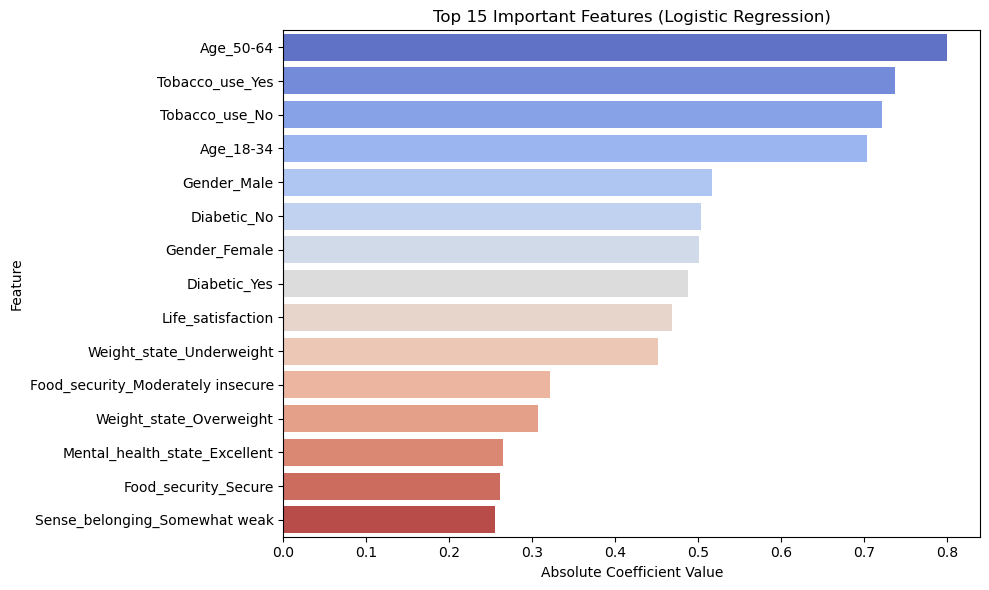

In [22]:
# Extract feature names
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(ohe_feature_names) + numeric_cols

# Get logistic regression coefficients
logreg_coefs = logreg_pipeline.named_steps['classifier'].coef_[0]

# Create DataFrame for top features
logreg_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': logreg_coefs})
logreg_df['Abs_Importance'] = logreg_df['Importance'].abs()
logreg_df = logreg_df.sort_values(by='Abs_Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=logreg_df, x='Abs_Importance', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Top 15 Important Features (Logistic Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Rationale:**
Logistic regression assigns each feature a coefficient that reflects its effect on the outcome. By taking the absolute value, we focus on the most influential predictors, regardless of whether they increase or decrease the likelihood of cannabis use.

**Interpretation:**
Age and tobacco use stand out as the strongest predictors. For example, individuals aged 50–64 and those who reported tobacco use significantly influence model predictions. Other key features include sex, diabetes status, life satisfaction, weight perception, and food security. Notably, both protective and risk-related factors appear, such as high life satisfaction (potentially protective) versus moderate food insecurity (possibly predictive). This confirms that cannabis use is influenced by a complex interplay of demographic, behavioral, and psychosocial variables.

## 9.  Decision Tree Feature Importance
Which features influenced predictions most?

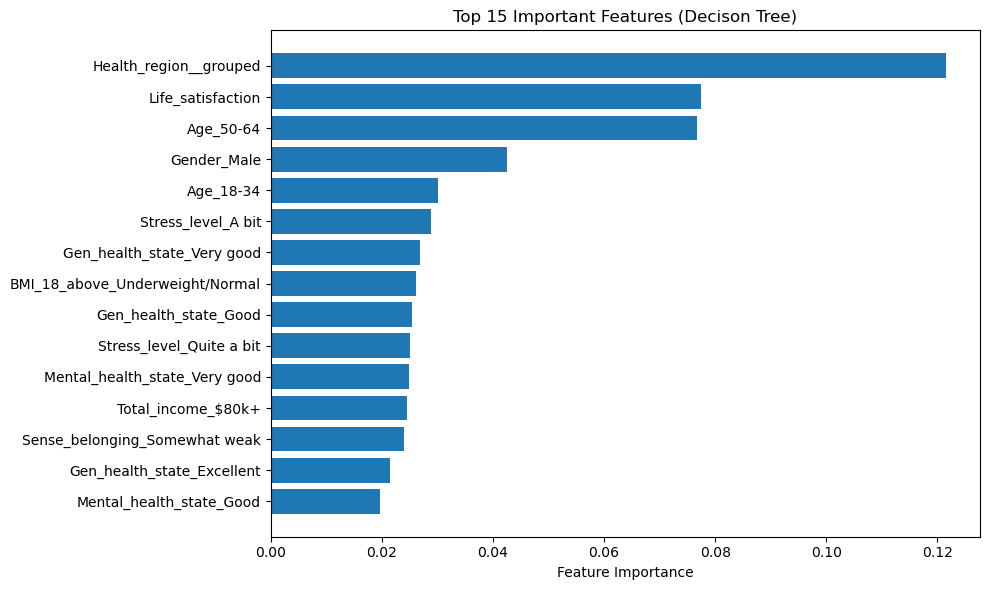

In [23]:
# Extract feature names from the one-hot encoder and combine with numeric column names
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(ohe_feature_names) + numeric_cols

# Retrieve feature importances from the decision tree model and sort them in descending order
importances = tree_pipeline.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the top 15 most important features used in predicting cannabis use
plt.figure(figsize=(10, 6))
plt.barh(range(15), importances[indices[:15]][::-1], align='center')
plt.yticks(range(15), [all_feature_names[i] for i in indices[:15]][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 15 Important Features (Decison Tree)')
plt.tight_layout()
plt.show()

**Rationale:**
Decision trees rank features based on how effectively they split the data to reduce impurity (i.e., improve prediction). The more a feature contributes to useful splits across the tree, the higher its importance score.

**Interpretation:**
Health_region_grouped and Life_satisfaction are the most influential predictors of cannabis use in the decision tree model. Age and gender also appear as key splits, aligning with findings from logistic regression. Psychosocial variables such as stress level, mental health, and sense of belonging show strong influence as well. This reinforces the idea that cannabis use is not just biologically or demographically driven, but also shaped by regional, emotional, and socioeconomic factors. This aligns with public health research that links substance use to demographic, psychological, and socioeconomic factors, supporting the model’s credibility.

## 10. ROC Curve Comparison
Visualizing model discrimination ability.

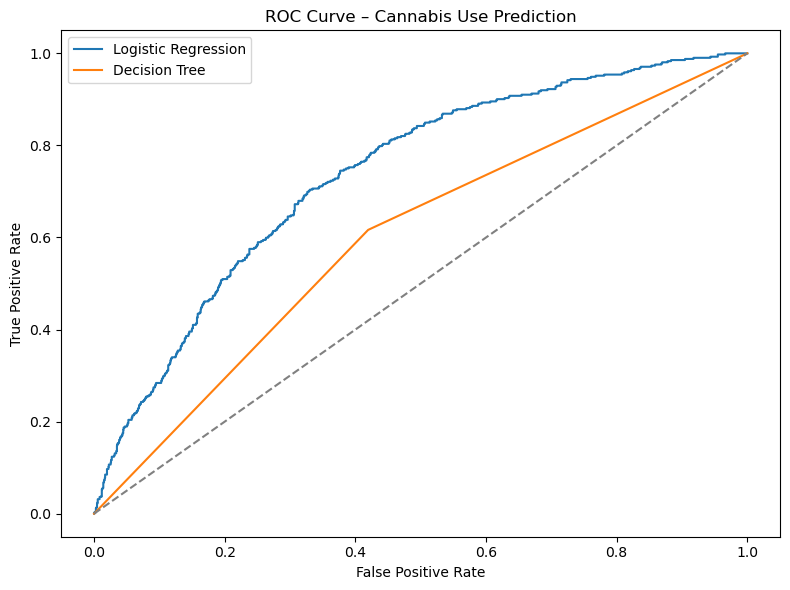

In [24]:
# Generate predicted probabilities for the positive class (Cannabis User)
logreg_probs = logreg_pipeline.named_steps['classifier'].predict_proba(X_test_transformed)[:, 1]
tree_probs = tree_pipeline.named_steps['classifier'].predict_proba(X_test_transformed)[:, 1]

# Calculate the false positive and true positive rates for each model
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg_probs)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)

# Plot the ROC curves to visualize and compare model performance
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Cannabis Use Prediction')
plt.legend()
plt.tight_layout()
plt.show()

**Rationale:**
The ROC curve evaluates a model’s ability to distinguish between classes by plotting the true positive rate against the false positive rate at various thresholds. It helps visualize how well each model separates cannabis users from non-users.

**Interpretation:**
Logistic Regression clearly outperforms the Decision Tree, with a higher curve that stays above the diagonal baseline. This means it does a better job ranking positive cases higher than negatives across thresholds. The Decision Tree performs only slightly better than random guessing. This visual supports earlier findings: logistic regression, especially after oversampling, is more effective for predicting cannabis use in this dataset.

## Conclusion
Random oversampling improved recall for cannabis users, raising it from 17% to 64% with logistic regression and from 34% to 62% with the decision tree. While accuracy decreased slightly, the models became more balanced in identifying both users and non-users. Logistic regression consistently outperformed the decision tree across precision, recall, and ROC curve analysis, making it the more reliable model for this task.

Feature importance analysis revealed that demographic (age, gender), behavioral (tobacco use), and psychosocial factors (life satisfaction, mental health, food security) played significant roles in predicting cannabis use. The decision tree also highlighted regional differences, further emphasizing the influence of environment.

Possible future steps include tuning hyperparameters, evaluating imputation strategies for missing data, and testing ensemble approaches such as Random Forests or Gradient Boosting to enhance performance and stability.